In [ ]:
import scipy.io
import numpy as np
import pickle
import pandas as pd

dataset = scipy.io.loadmat('./NeuroSignal Quest/data.set')

event_data = pd.read_csv ("./NeuroSignal Quest/events.tsv", sep = '\t')
signal = dataset['data']
time = dataset['times'][0]/1000
srate = 1/np.mean(np.diff(time))

event_time = np.array(event_data['onset'])
event_type = np.zeros(stim.shape)

events = {'standard':0, 'oddball':-1, 'oddball_with_reponse':1,'response':2, 'noise':3}

for i,e in enumerate(event_data['value']):
    event_type[i] = events[e]


variables = [signal, time, srate, event_time, event_type, events]

with open('./neuro2.pickle', 'wb') as h:
    pickle.dump(variables, h, protocol=pickle.HIGHEST_PROTOCOL)


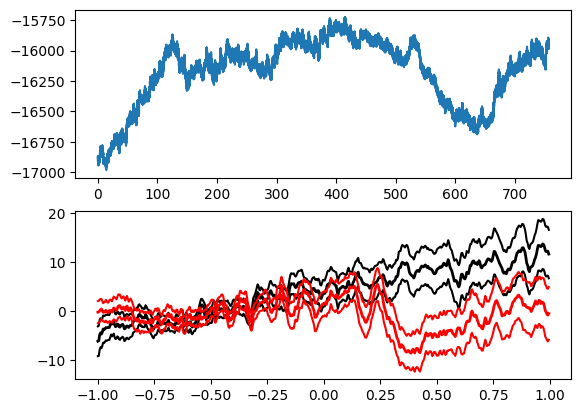

In [6]:
# Examples:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('./neuro2.pickle', 'rb') as h:
    [signal, time, srate, event_time, event_type, events] = pickle.load(h)


ich = 60

plt.subplot(2,1,1)
plt.plot(time,signal[ich,:])
# plt.plot(event_time,event_time*0+1,'.')

window = np.arange(-1*srate,1*srate, dtype = int)

# idx = np.where(event_type == 0)[0]

trials = np.zeros((signal.shape[0],window.shape[0]))
count = 0
for e in event_time[event_type == 0]:
    try:  
        trials[count,:] = signal[ich, int(e*srate//1) + window]
        trials[count,:] = trials[count,:]-np.mean(trials[count,:len(window)//2])
        count+=1
    except:
        pass

m = np.mean(trials, axis=0)
s = np.std(trials, axis=0)/np.sqrt(count)

plt.subplot(2,1,2)
plt.plot(window/srate,m,'k',linewidth = 2)
plt.plot(window/srate,m+s,'k')
plt.plot(window/srate,m-s,'k')

trials = np.zeros((signal.shape[0],window.shape[0]))
count = 0
for e in event_time[event_type == 1]:
    try:  
        trials[count,:] = signal[ich, int(e*srate//1) + window]
        trials[count,:] = trials[count,:]-np.mean(trials[count,:len(window)//2])
        count+=1
    except:
        pass

m = np.mean(trials, axis=0)
s = np.std(trials, axis=0)/np.sqrt(count)

plt.subplot(2,1,2)
plt.plot(window/srate,m,'r',linewidth = 2)
plt.plot(window/srate,m+s,'r')
plt.plot(window/srate,m-s,'r')